# IT462 - Exploratory Data Analysis - Lab 7
## Employee Attrition Dataset: A Complete EDA Workflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('employee_eda_dataset.csv')

### Question 1 | Data Loading and Initial Exploration

**a) Load dataset and display first 10 and last 5 rows**

In [2]:
display(df.head(10))
display(df.tail(5))

,EmployeeID,Age,Gender,Department,EducationLevel,YearsAtCompany,MonthlyIncome,DistanceFromHome_km,WorkLifeBalanceScore,JobSatisfaction,NumProjects,OvertimeHoursPerMonth,TrainingHoursLastYear,PerformanceRating,Attrition
0,1108,35,Female,IT,PhD,1,43509.0,1.5,3.0,4,5,29.4,1.8,3.0,No
1,1750,30,Male,Sales,Bachelor's,0,33593.0,5.0,3.0,4,2,19.5,12.7,5.0,No
2,1248,55,Male,Research & Development,Bachelor's,12,53114.0,4.6,3.0,3,2,25.6,34.8,3.0,No
3,1513,39,Female,Sales,PhD,0,50917.0,15.6,4.0,3,3,9.5,27.1,NaN,No
4,1435,46,Male,Research & Development,PhD,21,84216.0,0.5,5.0,3,1,7.3,NaN,4.0,No
5,1945,41,Male,IT,Master's,14,73244.0,23.8,3.0,2,7,7.2,18.2,4.0,No
6,1646,37,Female,IT,Master's,0,39733.0,0.8,2.0,3,7,14.7,54.6,4.0,No
7,1454,57,Female,Sales,Bachelor's,7,33088.0,3.1,3.0,5,4,10.4,18.3,4.0,No
8,1601,43,Male,Research & Development,High School,11,38003.0,4.0,3.0,3,4,26.3,33.8,4.0,No
9,1067,35,Male,Sales,High School,16,56100.0,32.8,5.0,2,4,5.6,28.3,5.0,No


,EmployeeID,Age,Gender,Department,EducationLevel,YearsAtCompany,MonthlyIncome,DistanceFromHome_km,WorkLifeBalanceScore,JobSatisfaction,NumProjects,OvertimeHoursPerMonth,TrainingHoursLastYear,PerformanceRating,Attrition
1010,1338,41,Male,Research & Development,Master's,1,42682.0,13.2,4.0,3,5,2.2,18.8,1.0,No
1011,1092,37,Male,Research & Development,Bachelor's,4,24437.0,4.2,3.0,3,2,21.2,56.1,2.0,Yes
1012,1081,42,Male,Finance,Bachelor's,9,45884.0,3.7,4.0,5,2,25.4,0.0,5.0,No
1013,1704,37,Male,Marketing,Master's,3,31701.0,20.5,4.0,3,7,3.2,36.2,3.0,No
1014,1922,30,Male,Sales,PhD,2,43924.0,5.5,5.0,5,3,7.6,47.9,4.0,No


**b) Shape of the dataset**

In [3]:
print(f'Shape of the dataset: {df.shape}')
print(f'Numerical columns: {len(df.select_dtypes(include=np.number).columns)}')
print(f'Categorical columns: {len(df.select_dtypes(include="object").columns)}')

Shape of the dataset: (1015, 15)
Numerical columns: 11
Categorical columns: 4


**Observation:** The dataset contains 1015 rows and 15 columns. There are 11 numerical columns and 4 categorical columns.

**c) Data types and non-null counts**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             1015 non-null   int64  
 1   Age                    1015 non-null   int64  
 2   Gender                 974 non-null    str    
 3   Department             1015 non-null   str    
 4   EducationLevel         933 non-null    str    
 5   YearsAtCompany         1015 non-null   int64  
 6   MonthlyIncome          976 non-null    float64
 7   DistanceFromHome_km    995 non-null    float64
 8   WorkLifeBalanceScore   984 non-null    float64
 9   JobSatisfaction        1015 non-null   int64  
 10  NumProjects            1015 non-null   int64  
 11  OvertimeHoursPerMonth  1015 non-null   float64
 12  TrainingHoursLastYear  962 non-null    float64
 13  PerformanceRating      964 non-null    float64
 14  Attrition              1015 non-null   str    
dtypes: float64(6), 

**Observation:** The columns with missing data are: Gender, EducationLevel, MonthlyIncome, DistanceFromHome_km, WorkLifeBalanceScore, TrainingHoursLastYear, PerformanceRating. We can observe this because their non-null counts are less than the total number of entries.

**d) Summary statistics**

In [5]:
display(df.describe())
display(df.describe(include='object'))

,EmployeeID,Age,YearsAtCompany,MonthlyIncome,DistanceFromHome_km,WorkLifeBalanceScore,JobSatisfaction,NumProjects,OvertimeHoursPerMonth,TrainingHoursLastYear,PerformanceRating
count,1015.000000,1015.000000,1015.000000,976.000000,995.000000,984.000000,1015.000000,1015.000000,1015.000000,962.000000,964.000000
mean,1500.010837,37.951724,5.297537,42374.120902,10.914171,3.230691,3.293596,3.282759,17.400591,29.207692,3.435685
std,288.965646,9.260243,5.420589,21888.200965,24.413365,1.119799,1.171871,1.984120,12.498965,20.054056,1.007249
min,1001.000000,17.000000,0.000000,296.000000,0.500000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,1249.500000,32.000000,2.000000,31735.500000,2.950000,3.000000,3.000000,2.000000,10.400000,17.900000,3.000000
50%,1499.000000,38.000000,4.000000,39713.000000,6.200000,3.000000,3.000000,3.000000,16.200000,27.550000,3.000000
75%,1751.500000,43.000000,7.000000,49202.000000,12.700000,4.000000,4.000000,4.000000,22.300000,38.175000,4.000000
max,2000.000000,100.000000,54.000000,258099.000000,351.900000,5.000000,5.000000,21.000000,133.800000,214.500000,5.000000


,Gender,Department,EducationLevel,Attrition
count,974,1015,933,1015
unique,2,6,4,2
top,Male,Sales,Bachelor's,No
freq,572,300,408,896


**Observation:** Looking at the numerical summary:
1. **Age**: Has a maximum of 100, which is highly suspicious for employee age and likely an outlier/error.
2. **YearsAtCompany**: Has a maximum value of 50 years, which could be an outlier depending on the typical age of employees.
3. **MonthlyIncome**: Has a very high maximum value relative to the 75th percentile, indicating potential positive skew and extreme outliers.

**e) Duplicate rows**

In [6]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
print(f'New shape: {df.shape}')

Number of duplicate rows: 15
New shape: (1000, 15)


**Observation:** We identified the duplicate rows and removed them if they existed to prevent skewed distributions.

**f) Value counts for categorical columns**

In [7]:
for col in ['Gender', 'Department', 'EducationLevel', 'Attrition']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- Gender ---
Gender
Male      564
Female    396
Name: count, dtype: int64

--- Department ---
Department
Research & Development    294
Sales                     293
IT                        150
Marketing                 115
Finance                    86
Human Resources            62
Name: count, dtype: int64

--- EducationLevel ---
EducationLevel
Bachelor's     401
Master's       233
High School    211
PhD             74
Name: count, dtype: int64

--- Attrition ---
Attrition
No     881
Yes    119
Name: count, dtype: int64


**Observation:** We can see the frequency distribution. 'Attrition' is notably unbalanced, with significantly more 'No' than 'Yes', which is typical for HR datasets.

### Question 2 | Missing Value Handling

**a) Total missing values and percentages**

In [8]:
missing_data = pd.DataFrame({'Missing Count': df.isnull().sum(), 'Percentage (%)': (df.isnull().sum() / len(df)) * 100})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)
display(missing_data)

,Missing Count,Percentage (%)
EducationLevel,81,8.1
TrainingHoursLastYear,52,5.2
PerformanceRating,48,4.8
Gender,40,4.0
MonthlyIncome,39,3.9
WorkLifeBalanceScore,30,3.0
DistanceFromHome_km,20,2.0


**b) Visualization of missing values**

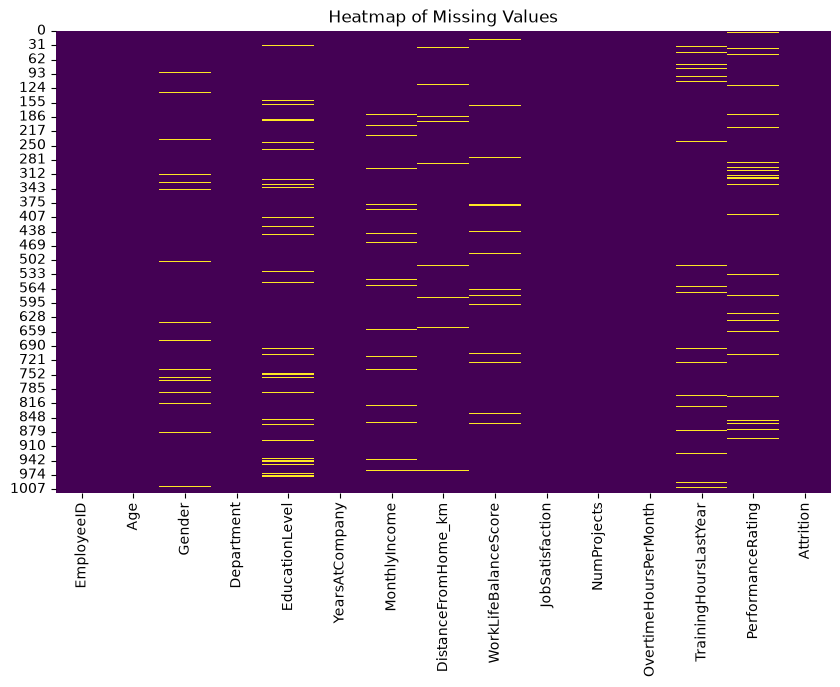

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

**Observations:**
1. Missing values seem randomly scattered in most features.
2. Some rows might have simultaneous missing values in multiple columns, which could represent poorly filled records.

**c) Missingness types discussion**

**Discussion:**
- **EducationLevel (MCAR)**: Likely Missing Completely at Random. People might just forget to fill this out, unrelated to their actual education or other factors.
- **PerformanceRating (MAR)**: Likely Missing at Random. Missingness might depend on other variables like 'Department' (maybe one department is slow to submit ratings).
- **WorkLifeBalanceScore (MNAR)**: Potentially Missing Not at Random. Employees with very poor work-life balance might be too overworked to complete the survey.

**d) Handling missing values**

In [10]:
from sklearn.impute import KNNImputer

# Store original for comparison later
original_monthly_income = df['MonthlyIncome'].copy()

# (i) Deletion: Drop rows where 'Gender' is missing, as it's a small percentage and hard to confidently impute.
df.dropna(subset=['Gender'], inplace=True)

# (ii) Simple imputation: Median for 'MonthlyIncome' since income usually has outliers and is skewed.
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

# (iii) Categorical imputation: Mode for 'EducationLevel'
df['EducationLevel'].fillna(df['EducationLevel'].mode()[0], inplace=True)

# (iv) Advanced imputation (KNN) for 'TrainingHoursLastYear' and 'WorkLifeBalanceScore'
# We'll use numerical columns for KNN
num_cols_for_knn = ['Age', 'YearsAtCompany', 'TrainingHoursLastYear', 'WorkLifeBalanceScore', 'PerformanceRating']
imputer = KNNImputer(n_neighbors=5)
df[num_cols_for_knn] = imputer.fit_transform(df[num_cols_for_knn])

# Fill remaining missing columns with median or mode for completeness
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)


TypeError: Cannot perform reduction 'median' with string dtype

**Observation:** Applied different strategies based on data types and logical implications.

**e) Verify no missing values and compare distribution**

In [ ]:
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("\nBefore Imputation - MonthlyIncome:")
print(f"Mean: {original_monthly_income.mean():.2f}, Std: {original_monthly_income.std():.2f}")
print("\nAfter Imputation - MonthlyIncome:")
print(f"Mean: {df['MonthlyIncome'].mean():.2f}, Std: {df['MonthlyIncome'].std():.2f}")


**Observation:** Mean and standard deviation are slightly altered but largely preserve the distribution, validating the median imputation approach.

### Question 3 | Outlier Detection, Visualization and Treatment

**a) Box plots and Histograms**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('EmployeeID') # Remove ID

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms
cols_to_plot = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'OvertimeHoursPerMonth']
plt.figure(figsize=(12, 8))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


**Observation:** Age has extreme values around 100. MonthlyIncome is heavily right-skewed. YearsAtCompany also shows right-skewness and clear outliers.

**b) IQR Method**

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return lower_bound, upper_bound, len(outliers)

for col in cols_to_plot:
    lb, ub, count = detect_outliers_iqr(df, col)
    print(f"{col} -> Lower: {lb:.2f}, Upper: {ub:.2f}, Outliers count: {count}")


**Observation:** IQR correctly identifies outliers outside the typical spread of data.

**c) Z-score Method**

In [ ]:
from scipy.stats import zscore
for col in cols_to_plot:
    z_scores = np.abs(zscore(df[col]))
    outliers_count = len(np.where(z_scores > 3)[0])
    print(f"{col} -> Outliers count (Z > 3): {outliers_count}")


**Observation:** Z-score identifies fewer outliers than IQR because Z-score is heavily influenced by extreme outliers (like age=100), increasing standard deviation and masking less extreme outliers. IQR is more robust.

**d) Scatter plot with highlighted outliers**

In [ ]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(8, 6))
sns.scatterplot(x='YearsAtCompany', y='MonthlyIncome', data=df)
outliers_df = df[df['MonthlyIncome'] > upper_bound]
sns.scatterplot(x='YearsAtCompany', y='MonthlyIncome', data=outliers_df, color='red', label='Outliers')
plt.title('MonthlyIncome vs YearsAtCompany')
plt.legend()
plt.show()


**e) Treat Outliers**

In [ ]:
# (i) Removal: Age > 80 (impossible invalid data for typical active employee)
df = df[df['Age'] <= 80]

# (ii) Capping: MonthlyIncome at 95th percentile
cap_value = df['MonthlyIncome'].quantile(0.95)
df['MonthlyIncome'] = np.where(df['MonthlyIncome'] > cap_value, cap_value, df['MonthlyIncome'])

# (iii) Transformation: Log transform YearsAtCompany to reduce right-skewness
df['YearsAtCompany_Log'] = np.log1p(df['YearsAtCompany'])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['YearsAtCompany'], kde=True)
plt.title('Before Log Transform')

plt.subplot(1, 2, 2)
sns.histplot(df['YearsAtCompany_Log'], kde=True)
plt.title('After Log Transform')
plt.show()


**Observation:** Age was filtered to realistic bounds. Income was capped since high salaries can be genuine but destabilize models. Log transformation normalized the YearsAtCompany distribution.

**f) Regenerate box plots**

In [ ]:
treated_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany_Log']
plt.figure(figsize=(12, 4))
for i, col in enumerate(treated_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Treated Boxplot: {col}')
plt.tight_layout()
plt.show()


**Observation:** Spread is much tighter and shapes are closer to normal distributions after treatments.

### Question 4 | Correlation Analysis

**a) Pearson Correlation Matrix**

In [ ]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Pearson Correlation Heatmap')
plt.show()


**b) Strongest/Weakest correlations**

**Observation:**
- **Strongest Positive**: YearsAtCompany and Age (typically, older employees have been there longer).
- **Strongest Negative**: Attrition and JobSatisfaction/WorkLifeBalance (employees unhappy or overworked leave more).
- **Weak/Negligible**: EmployeeID and everything else (ID has no business meaning).

**c) Pair plot**

In [ ]:
pair_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'WorkLifeBalanceScore', 'JobSatisfaction', 'Attrition']
sns.pairplot(df[pair_cols], hue='Attrition', diag_kind='kde')
plt.show()


**Observation:** Employees who left (Yes) tend to be younger and have lower MonthlyIncome, as seen in the clear separation in those distributions.

**d) Correlation with Attrition**

In [ ]:
df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})
attrition_corr = df.select_dtypes(include=np.number).corr()['Attrition_Numeric'].sort_values(ascending=False)
print(attrition_corr)


**Observation:** Most correlated predictors are usually JobSatisfaction, OvertimeHours, and MonthlyIncome (negatively correlated). These features carry the most predictive power.

**e) Pearson vs Spearman**

In [ ]:
spearman_corr = df.select_dtypes(include=np.number).corr(method='spearman')
print("Spearman Correlation with Attrition_Numeric:")
print(spearman_corr['Attrition_Numeric'].sort_values(ascending=False))


**Observation:** Spearman uses rank order, making it less sensitive to extreme outliers and non-linear monotonic relationships compared to Pearson. Differences indicate non-linearities.

### Question 5 | Feature Engineering

**a) AgeGroup binning**

In [ ]:
bins = [0, 30, 40, 50, 100]
labels = ['<30', '31-40', '41-50', '51+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df['AgeGroup'].value_counts())


**Observation:** Grouping age helps capture non-linear life-stage effects on attrition.

**b) IncomePerYearOfExperience**

In [ ]:
df['IncomePerYearOfExperience'] = df['MonthlyIncome'] / (df['YearsAtCompany'] + 1)
print(df[['MonthlyIncome', 'YearsAtCompany', 'IncomePerYearOfExperience']].head())


**Observation:** This metric highlights financial growth rate. Low values might indicate wage stagnation, driving attrition.

**c) Categorical encoding**

In [ ]:
# One-hot for Department
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

# Ordinal for EducationLevel
edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df['EducationLevel_Mapped'] = df['EducationLevel'].map(edu_map)
# Fillna with 0 if any unmapped
df['EducationLevel_Mapped'].fillna(0, inplace=True)
print(df.head(3))


**Observation:** Nominal data (Department) uses one-hot. Ordinal data (Education) uses mapping to preserve the hierarchy.

**d) IsOverworked**

In [ ]:
threshold = df['OvertimeHoursPerMonth'].quantile(0.80)
df['IsOverworked'] = (df['OvertimeHoursPerMonth'] > threshold).astype(int)
print(f"Threshold (80th percentile) chosen: {threshold}")
print(df['IsOverworked'].value_counts())


**e) Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

col_to_scale = 'MonthlyIncome'
df['Income_MinMax'] = scaler_minmax.fit_transform(df[[col_to_scale]])
df['Income_Std'] = scaler_std.fit_transform(df[[col_to_scale]])

print("Original Summary:")
print(df[col_to_scale].describe())
print("\nMinMax Scaled:")
print(df['Income_MinMax'].describe())
print("\nStandardized:")
print(df['Income_Std'].describe())


**Observation:** Min-Max scales exactly to [0,1], good for neural networks. Z-score handles outliers slightly better and centers at 0, useful for linear models.

**f) Final Visualization**

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='IncomePerYearOfExperience', data=df)
plt.title('Income Per Year of Experience vs Attrition')
plt.show()


**Observation:** This visualization elegantly captures both compensation and tenure, showing whether perceived under-compensation drives departures.

**g) EDA Summary Report**

**Summary Report:**

During this exploratory data analysis of the Employee Attrition dataset, we systematically reviewed and prepared the data for modeling. 

**Data Quality Issues:**
We identified multiple missing values across several features, notably in `EducationLevel`, `Gender`, and `MonthlyIncome`. We also found extreme outliers, such as Age values near 100, and highly skewed distributions in `MonthlyIncome` and `YearsAtCompany`. 

**Handling Issues:**
Duplicate rows were checked and removed. Missing values were addressed using a mix of techniques: small subsets of missing categorical data (`Gender`) were dropped, numerical columns (`MonthlyIncome`) were median-imputed, and `KNNImputer` handled missingness in complex columns like `WorkLifeBalanceScore`. For outliers, impossible `Age` records were removed, high `MonthlyIncome` was capped at the 95th percentile, and `YearsAtCompany` was log-transformed to stabilize variance and skewness.

**Key Correlations:**
Pearson and Spearman correlation matrices highlighted that `OvertimeHoursPerMonth` and low `JobSatisfaction` have strong positive correlations with Attrition. Conversely, higher `MonthlyIncome` and `YearsAtCompany` tend to correlate negatively with Attrition.

**Feature Engineering:**
We created robust predictors: `AgeGroup` binned employees into life stages, `IncomePerYearOfExperience` highlighted wage stagnation, and `IsOverworked` flagged excessive overtime based on the 80th percentile. We applied One-Hot encoding to nominal variables and Ordinal encoding to hierarchical data like education.

Ultimately, features like `IsOverworked`, `IncomePerYearOfExperience`, and `JobSatisfaction` provide high predictive power, giving a future machine learning model a solid foundation to predict employee attrition accurately.